# Laboratorio 2: 05 Síntesis Visual y Animación Temporal

Este notebook integra las visualizaciones finales y genera animaciones temporales (GIF) de la expansión urbana y la vegetación.

---

In [1]:
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re
import imageio.v2 as imageio
import os
import geopandas as gpd
from matplotlib.colors import ListedColormap

# Configuración de rutas
proc_path = Path('../data/processed')
vector_path = Path('../data/vector')
fig_path = Path('../outputs/figures')
fig_path.mkdir(exist_ok=True, parents=True)

change_tif = proc_path / 'cambio_clasificado.tif'
limite_path = vector_path / 'limite_comuna.gpkg'

## 1. Animaciones Temporales (Time-lapses)

Generamos GIFs para visualizar la dinámica territorial desde dos perspectivas: Expansión Urbana (NDBI) y Salud de la Vegetación (NDVI).

In [2]:
indices_files = sorted(proc_path.glob('indices_*.tif'))
limite = gpd.read_file(limite_path)

def generar_gif(modo, nombre_archivo, cmap, vmin, vmax, titulo_prefijo):
    frames = []
    print(f"Generando frames para {modo}...")
    for f in indices_files:
        year = re.search(r'\d{4}', f.name).group()
        with rasterio.open(f) as src:
            idx = 1 if modo == 'NDVI' else 2
            data = src.read(idx)
            
            limite_utm = limite.to_crs(src.crs)
            minx, miny, maxx, maxy = limite_utm.total_bounds
            margin = (maxx - minx) * 0.15
            
            fig, ax = plt.subplots(figsize=(10, 10), dpi=80)
            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
            ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent)
            limite_utm.plot(ax=ax, edgecolor='cyan', facecolor='none', linestyle='--', linewidth=3)
            
            ax.set_xlim(minx - margin, maxx + margin)
            ax.set_ylim(miny - margin, maxy + margin)
            ax.set_title(f"{titulo_prefijo}: {year}", fontsize=25, color='white', pad=20)
            ax.axis('off')
            
            fig.patch.set_facecolor('#0e1117')
            plt.tight_layout()
            
            temp_png = f"temp_{modo}_{year}.png"
            plt.savefig(temp_png, facecolor=fig.get_facecolor())
            plt.close()
            
            frames.append(imageio.imread(temp_png))
            os.remove(temp_png)

    imageio.mimsave(fig_path / nombre_archivo, frames, duration=1000, loop=0)
    print(f"✅ GIF {nombre_archivo} generado con éxito!")

# Generar ambos
generar_gif('NDBI', 'evolucion_urbana.gif', 'magma', -0.1, 0.4, 'Expansión Urbana')
generar_gif('NDVI', 'evolucion_vegetacion.gif', 'viridis', -0.2, 0.8, 'Vigor Vegetación')

Generando frames para NDBI...
✅ GIF evolucion_urbana.gif generado con éxito!
Generando frames para NDVI...
✅ GIF evolucion_vegetacion.gif generado con éxito!


## 2. Mapa de Síntesis de Cambios

Visualización del mapa final de detección multitemporal.

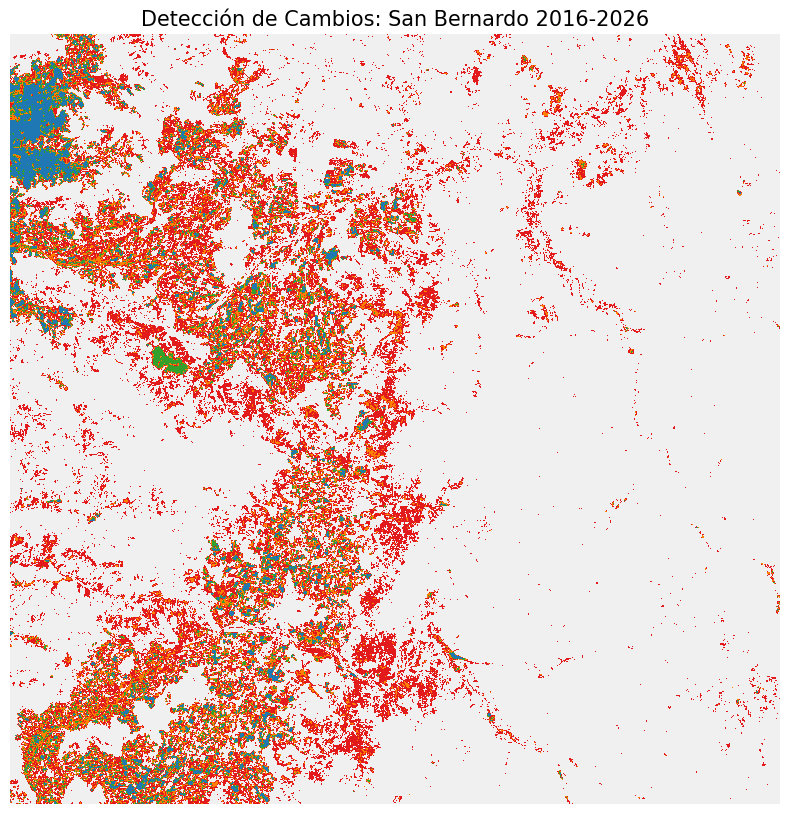

In [3]:
if change_tif.exists():
    with rasterio.open(change_tif) as src:
        data = src.read(1)
        colors = ['#f0f0f0', '#e31a1c', '#ff7f00', '#33a02c', '#1f78b4']
        cmap = ListedColormap(colors)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(data, cmap=cmap)
        plt.title("Detección de Cambios: San Bernardo 2016-2026", fontsize=15)
        plt.axis('off')
        plt.show()
else:
    print("El archivo de cambios no existe. Procese el Notebook 03.")

## 3. Instrucciones del Dashboard

Acceda a la aplicación interactiva para profundizar en el análisis:

*   **Localhost:** [http://localhost:8502](http://localhost:8502) (o el puerto configurado).